1 - first up is to just import my data and visualise it to get a feel for what im working with

In [7]:
import os
import pandas as pd

df1 = pd.read_csv("/Users/wes/Documents/Uptrail/Week 2/Project Files/customer_info.csv")

In [9]:
df1.head()

,customer_id,email,signup_date,gender,gender_clean,region,loyalty_tier,layalty_clean
0,C00001,shaneramirez@gmail.com,2025-04-26,Male,Male,Central,Silver,Silver
1,C00002,jpeterson@bernard.com,2024-08-11,Female,Female,Central,Gold,Gold
2,C00003,howardmaurice@yahoo.com,2025-05-15,male,Male,Central,Gold,Gold
3,C00004,yherrera@arnold.org,2025-06-14,FEMALE,Female,Central,Gold,Gold
4,C00005,janetwilliams@gmail.com,2025-05-02,Male,Male,West,bronze,Bronze


In [11]:
df2 = pd.read_csv("/Users/wes/Documents/Uptrail/Week 2/Project Files/product_info.csv")

In [12]:
df2.head()

,product_id,product_name,category,launch_date,base_price,supplier_code
0,P0001,Storage Product 39,Storage,11-03-25,15.88,S339
1,P0002,Cleaning Product 82,Cleaning,18-08-24,34.23,S974
2,P0003,Cleaning Product 85,Cleaning,15-07-24,7.92,S745
3,P0004,Kitchen Product 82,Kitchen,19-04-25,9.13,S589
4,P0005,Personal Care Product 1,Personal Care,20-10-24,31.10,S559


In [13]:
df3 = pd.read_csv("/Users/wes/Documents/Uptrail/Week 2/Project Files/sales_data.csv")

df3.head()

,order_id,customer_id,product_id,quantity,qty_clean,unit_price,order_date,delivery_status,delivery_clean,payment_method,payment_clean,region,discount_applied
0,O966977,C00397,P0022,3.0,3.0,39.25,2025-07-06,Delivered,Delivered,PayPal,Paypal,Central,0.00
1,O696648,C00236,P0023,5.0,5.0,18.92,2025-07-06,DELAYED,Delayed,credit card,Credit Card,North,0.00
2,O202644,C00492,P0011,1.0,1.0,29.68,2025-07-07,delivered,Delivered,Bank Transfer,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1.0,1.0,32.76,2025-07-08,Cancelled,Cancelled,Credit Card,Credit Card,Central,0.20
4,O322242,C00495,P0016,1.0,1.0,47.62,2025-07-08,DELAYED,Delayed,Credit Card,Credit Card,West,0.20


2 - next is to start cleaning up some the columns so they're uniform (no blank space or inconsistent casing)

In [14]:
df1['gender'] = df1['gender'].str.title()
df1['loyalty_tier'] = df1['loyalty_tier'].str.strip().str.title()

In [15]:
df1['region'] = df1['region'].str.title()

In [16]:
df1.head()

,customer_id,email,signup_date,gender,gender_clean,region,loyalty_tier,layalty_clean
0,C00001,shaneramirez@gmail.com,2025-04-26,Male,Male,Central,Silver,Silver
1,C00002,jpeterson@bernard.com,2024-08-11,Female,Female,Central,Gold,Gold
2,C00003,howardmaurice@yahoo.com,2025-05-15,Male,Male,Central,Gold,Gold
3,C00004,yherrera@arnold.org,2025-06-14,Female,Female,Central,Gold,Gold
4,C00005,janetwilliams@gmail.com,2025-05-02,Male,Male,West,Bronze,Bronze


3 - then standardise the date format

In [17]:
df1['signup_date'] = pd.to_datetime(df1['signup_date'], format='%d/%m/%Y')

ValueError: time data "2025-04-26" doesn't match format "%d/%m/%Y", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [18]:
df1.head()

,customer_id,email,signup_date,gender,gender_clean,region,loyalty_tier,layalty_clean
0,C00001,shaneramirez@gmail.com,2025-04-26,Male,Male,Central,Silver,Silver
1,C00002,jpeterson@bernard.com,2024-08-11,Female,Female,Central,Gold,Gold
2,C00003,howardmaurice@yahoo.com,2025-05-15,Male,Male,Central,Gold,Gold
3,C00004,yherrera@arnold.org,2025-06-14,Female,Female,Central,Gold,Gold
4,C00005,janetwilliams@gmail.com,2025-05-02,Male,Male,West,Bronze,Bronze


In [19]:
df3['order_date'] = pd.to_datetime(df3['order_date'], format='mixed')
df2['launch_date'] = pd.to_datetime(df2['launch_date'], format='mixed')

4 - then i looked for any other inconsistencies in excel from a sample of data (i do this because it's easier to see all the data in excel) then come back to python to change it cleanly

In [20]:
df1['gender'] = df1['gender'].replace('femle', 'Female')
df1['loyalty_tier'] = df1['loyalty_tier'].replace('gld', 'Gold')
df1['loyalty_tier'] = df1['loyalty_tier'].replace('brnze', 'Bronze')


5 - first attempt to clean this column failed

In [23]:
df3['delivery_status'] = df3['delivery_status'].replace('delrd', 'Delivered')
df3['delivery_status'] = df3['delivery_status'].replace('delyd', 'Delayed')
df3['delivery_status'] = df3['delivery_status'].replace('DELAYED', 'Delayed')

df3.head()

,order_id,customer_id,product_id,quantity,qty_clean,unit_price,order_date,delivery_status,delivery_clean,payment_method,payment_clean,region,discount_applied
0,O966977,C00397,P0022,3.0,3.0,39.25,2025-07-06,Delivered,Delivered,PayPal,Paypal,Central,0.00
1,O696648,C00236,P0023,5.0,5.0,18.92,2025-07-06,Delayed,Delayed,credit card,Credit Card,North,0.00
2,O202644,C00492,P0011,1.0,1.0,29.68,2025-07-07,Delivered,Delivered,Bank Transfer,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1.0,1.0,32.76,2025-07-08,Cancelled,Cancelled,Credit Card,Credit Card,Central,0.20
4,O322242,C00495,P0016,1.0,1.0,47.62,2025-07-08,Delayed,Delayed,Credit Card,Credit Card,West,0.20


5a - so i stripped the column to account for blank space and used case=false command to account for the highly inconsistent casing in this column

In [22]:
df3['delivery_status'] = df3['delivery_status'].str.strip()

df3['delivery_status'] = df3['delivery_status'].str.replace('delrd', 'Delivered', case=False)
df3['delivery_status'] = df3['delivery_status'].str.replace('delyd', 'Delayed', case=False)
df3['delivery_status'] = df3['delivery_status'].str.replace('delayed', 'Delayed', case=False)
df3['delivery_status'] = df3['delivery_status'].str.replace('delivered', 'Delivered', case=False)

df3.head(10)

,order_id,customer_id,product_id,quantity,qty_clean,unit_price,order_date,delivery_status,delivery_clean,payment_method,payment_clean,region,discount_applied
0,O966977,C00397,P0022,3.0,3.0,39.25,2025-07-06,Delivered,Delivered,PayPal,Paypal,Central,0.00
1,O696648,C00236,P0023,5.0,5.0,18.92,2025-07-06,Delayed,Delayed,credit card,Credit Card,North,0.00
2,O202644,C00492,P0011,1.0,1.0,29.68,2025-07-07,Delivered,Delivered,Bank Transfer,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1.0,1.0,32.76,2025-07-08,Cancelled,Cancelled,Credit Card,Credit Card,Central,0.20
4,O322242,C00495,P0016,1.0,1.0,47.62,2025-07-08,Delayed,Delayed,Credit Card,Credit Card,West,0.20
5,O190175,C00388,P0005,3.0,3.0,37.89,2025-07-10,Delayed,Delayed,Bank Transfer,Bank Transfer,North,0.10
6,O272646,C00328,P0027,5.0,5.0,30.83,2025-07-12,Delivered,Delivered,PayPal,Paypal,Central,0.05
7,O411881,C00201,P0019,3.0,3.0,12.56,2025-07-14,Delivered,Delivered,Credit Card,Credit Card,East,0.00
8,O170570,C00076,P0030,3.0,3.0,28.32,2025-07-16,Delivered,Delivered,PayPal,Paypal,Central,0.15
9,O619944,C00330,P0002,1.0,1.0,30.96,2025-07-18,Delayed,Delayed,Credit Card,Credit Card,South,0.15


In [42]:
df3['payment_method'] = df3['payment_method'].str.replace('bank transfr', 'bank transfer')
df3['payment_method'] = df3['payment_method'].str.title()

df3['payment_method'] = df3['payment_method'].str.replace('paypal', 'PayPal', case=False)

df3.head(5)

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
0,O966977,C00397,P0022,3,39.25,2025-07-06,Delivered,PayPal,Central,0.00
1,O696648,C00236,P0023,5,18.92,2025-07-06,Delayed,Credit Card,North,0.00
2,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1,32.76,2025-07-08,Cancelled,Credit Card,Central,0.20
4,O322242,C00495,P0016,1,47.62,2025-07-08,Delayed,Credit Card,West,0.20


In [43]:
df3['region'] = df3['region'].str.replace('nrth', 'North', case=False)

df3.head()

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
0,O966977,C00397,P0022,3,39.25,2025-07-06,Delivered,PayPal,Central,0.00
1,O696648,C00236,P0023,5,18.92,2025-07-06,Delayed,Credit Card,North,0.00
2,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1,32.76,2025-07-08,Cancelled,Credit Card,Central,0.20
4,O322242,C00495,P0016,1,47.62,2025-07-08,Delayed,Credit Card,West,0.20


6 - this was testing some of the visuals i learned to locate nulls

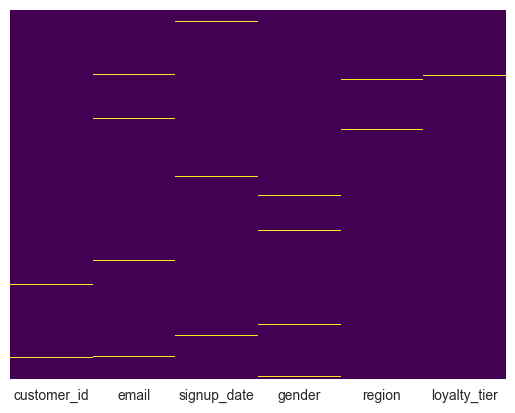

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Solid blocks of color mean data exists; lines/gaps mean NaNs
sns.heatmap(df1.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.show()

7 - here i was just trying to gauge where exactly the nulls i saw above were

In [58]:
null_rows = df1[df1['region'].isna()]

display(null_rows)

,customer_id,email,signup_date,gender,region,loyalty_tier
94,C00095,jeremy24@erickson.com,2024-07-23,Male,NaN,Gold
162,C00163,ronald45@mcdaniel.com,2024-10-08,Female,NaN,Silver
345,C00346,williamstone@hotmail.com,NaT,Male,NaN,Gold


7a - then changed them using .fillna and .iloc

In [59]:
df1['region'] = df1['region'].fillna('Unknown')

df1.iloc[[94, 162, 345]]

,customer_id,email,signup_date,gender,region,loyalty_tier
94,C00095,jeremy24@erickson.com,2024-07-23,Male,Unknown,Gold
162,C00163,ronald45@mcdaniel.com,2024-10-08,Female,Unknown,Silver
345,C00346,williamstone@hotmail.com,NaT,Male,Unknown,Gold


In [24]:
print(df3.duplicated().sum())

0


8 - email and customer_id CANNOT be duplicates so i address that here but discover that theyre simply NaNs so that's okay for now

In [64]:
email_dupes = df1[df1.duplicated(subset=['email'], keep=False)]
display(email_dupes)

id_dupes = df1[df1.duplicated(subset=['customer_id'], keep=False)]
display(id_dupes)

,customer_id,email,signup_date,gender,region,loyalty_tier
87,C00088,NaN,2025-06-01,Male,West,Bronze
147,C00148,NaN,2025-02-03,Male,West,Gold
303,C00304,NaN,2024-02-11,Male,East,Gold
339,C00340,NaN,2025-03-24,Male,Central,Bronze
375,C00376,NaN,2024-12-07,Femle,South,Bronze
469,C00470,NaN,2024-07-17,Femle,North,Silver


,customer_id,email,signup_date,gender,region,loyalty_tier
253,NaN,mark16@parker.com,2025-02-22,Femle,South,Bronze
371,NaN,ohayes@gmail.com,2024-09-12,Other,Central,Silver
470,NaN,nancygonzalez@wright.com,2025-06-27,Male,Central,Silver


9 - here i'm just checking for and unit prices < 0 which would of course be invalid

In [72]:
false_dc = df3.query('unit_price < 0')

false_dc

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied


8a - i discovered that the missing IDs could be filled via interpolation based on order of the gaps. eg. 252, 253, NaN, 255, 256 etc

In [26]:
df1.at[253, 'customer_id'] = 'C00254'
df1.at[371, 'customer_id'] = 'C00372'
df1.at[470, 'customer_id'] = 'C00471'

10 - time to create a master table using left joins

In [83]:
sales_with_products = df3.merge(df2, on='product_id', how='left')

master_df = sales_with_products.merge(df1, on='customer_id', how='left')

display(master_df.head())

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region_x,discount_applied,product_name,category,launch_date,base_price,supplier_code,email,signup_date,gender,region_y,loyalty_tier
0,O966977,C00397,P0022,3,39.25,2025-07-06,Delivered,PayPal,Central,0.00,Cleaning Product 86,Cleaning,2024-04-10,19.77,S924,jacquelinemartin@mills-logan.com,2024-08-09,Female,North,Silver
1,O696648,C00236,P0023,5,18.92,2025-07-06,Delayed,Credit Card,North,0.00,Outdoors Product 32,Outdoors,2025-01-18,36.04,S907,georgeweber@morgan.com,2024-06-08,Other,North,Gold
2,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,Kitchen Product 53,Kitchen,2025-03-25,11.08,S645,lcook@walters-smith.com,2024-09-25,Male,Central,Gold
3,O501803,C00031,P0003,1,32.76,2025-07-08,Cancelled,Credit Card,Central,0.20,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745,smoore@gmail.com,2024-07-28,Femle,Central,Gold
4,O322242,C00495,P0016,1,47.62,2025-07-08,Delayed,Credit Card,West,0.20,Cleaning Product 53,Cleaning,2025-02-20,26.71,S715,mcclainkatherine@hotmail.com,2024-09-18,Male,Central,Gold


11 - feature engineering new columns for analysis

In [84]:
master_df['revenue'] = master_df['unit_price'] * (1 - master_df['discount_applied'])

master_df['is_late'] = master_df['delivery_status'] == 'Delayed'

master_df['order_week'] = master_df['order_date'].dt.isocalendar().week

master_df['days_to_order'] = (master_df['order_date'] - master_df['launch_date']).dt.days

bins = [0, 15, 30, float('inf')]
labels = ['Low', 'Medium', 'High']
master_df['price_band'] = pd.cut(master_df['unit_price'], bins=bins, labels=labels, right=False)

master_df['email_domain'] = master_df['email'].str.split('@').str[1]

In [85]:
display(master_df.head())

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region_x,discount_applied,...,signup_date,gender,region_y,loyalty_tier,revenue,is_late,order_week,days_to_order,price_band,email_domain
0,O966977,C00397,P0022,3,39.25,2025-07-06,Delivered,PayPal,Central,0.00,...,2024-08-09,Female,North,Silver,39.250,False,27,452.0,High,mills-logan.com
1,O696648,C00236,P0023,5,18.92,2025-07-06,Delayed,Credit Card,North,0.00,...,2024-06-08,Other,North,Gold,18.920,True,27,169.0,Medium,morgan.com
2,O202644,C00492,P0011,1,29.68,2025-07-07,Delivered,Bank Transfer,North,0.15,...,2024-09-25,Male,Central,Gold,25.228,False,28,104.0,Medium,walters-smith.com
3,O501803,C00031,P0003,1,32.76,2025-07-08,Cancelled,Credit Card,Central,0.20,...,2024-07-28,Femle,Central,Gold,26.208,False,28,358.0,High,gmail.com
4,O322242,C00495,P0016,1,47.62,2025-07-08,Delayed,Credit Card,West,0.20,...,2024-09-18,Male,Central,Gold,38.096,True,28,138.0,High,hotmail.com


11a - and save the new table

In [27]:
master_df.to_csv("master_data.csv", index=False)

NameError: name 'master_df' is not defined

12 - now i have my new table i can make some actually useful visuals. i didnt use these in my final report as i was mostly just getting an understanding of visuals in python

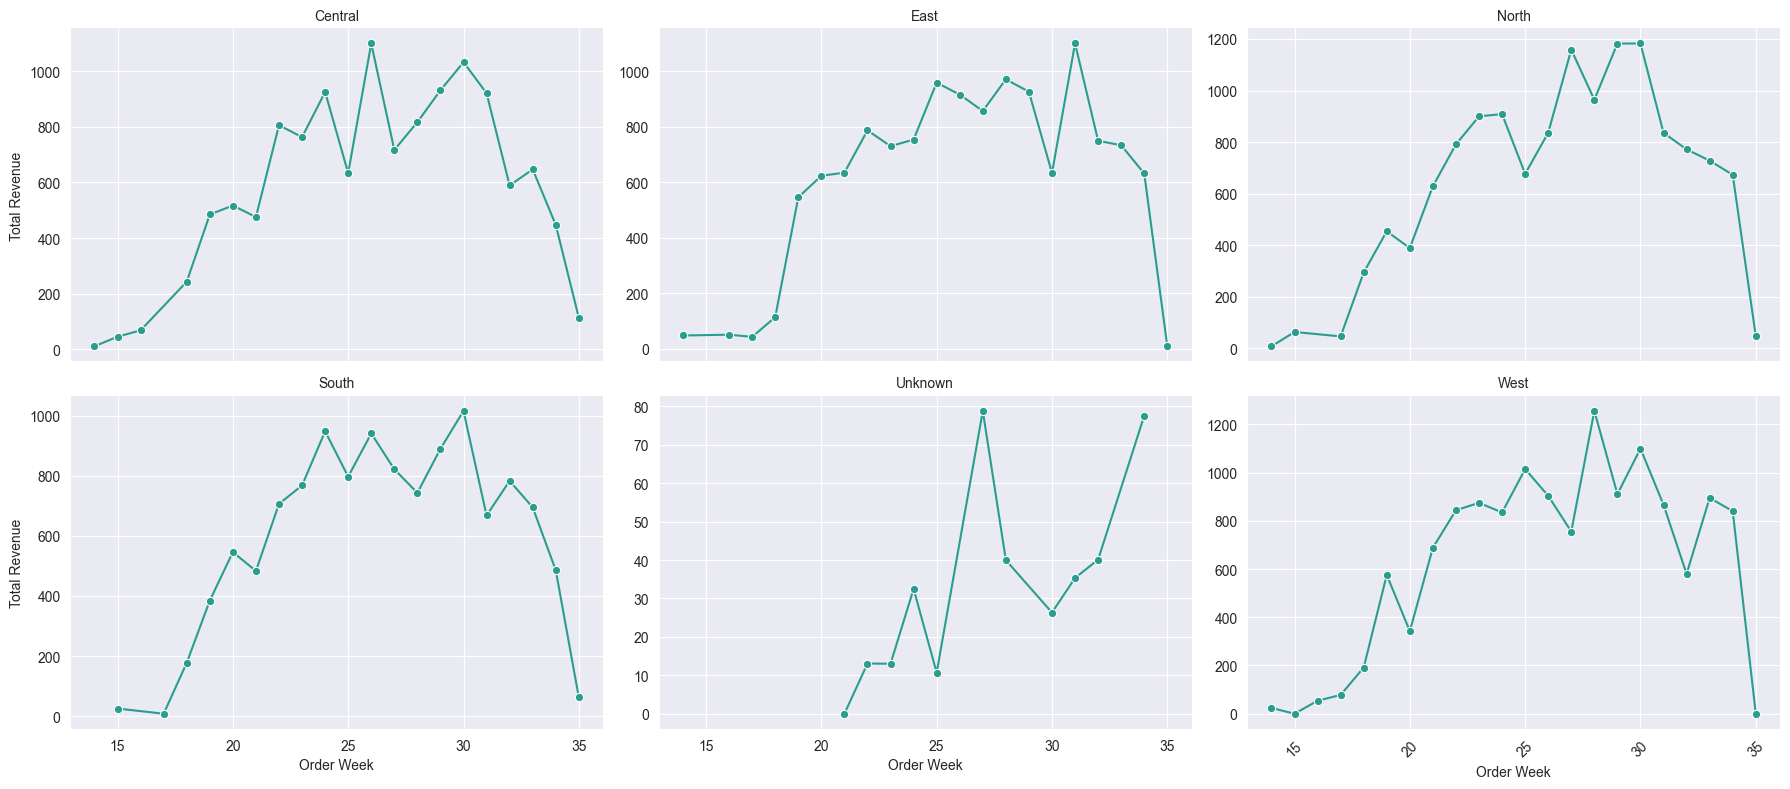

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = master_df.groupby(['region_y', 'order_week'])['revenue'].sum().reset_index()

g = sns.FacetGrid(plot_data, col="region_y", col_wrap=3,
                  height=4, aspect=1.5, sharey=False)

g.map_dataframe(sns.lineplot, x="order_week", y="revenue", marker="o", color="#2a9d8f")

g.set_axis_labels("Order Week", "Total Revenue")
g.set_titles("{col_name}")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

12a - this one shows clearly which category generates the most revenue

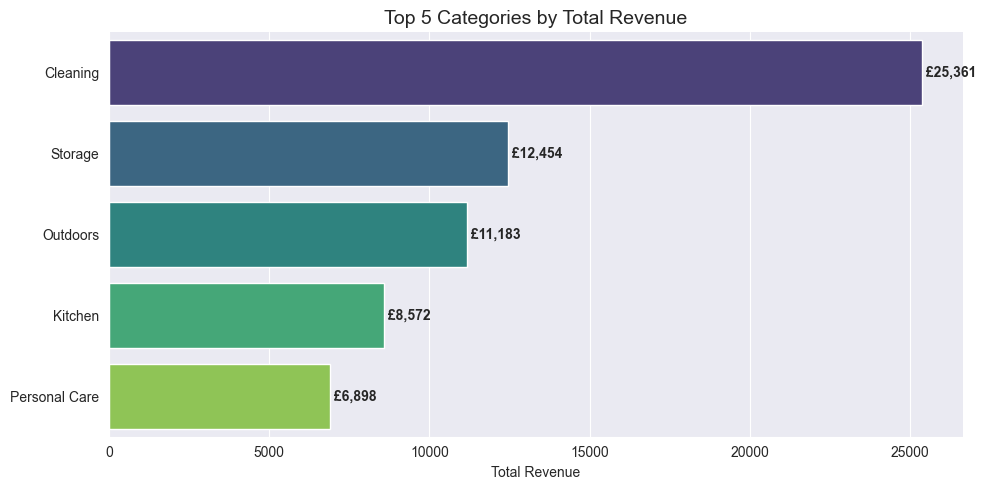

In [91]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_5_cats,
    x='revenue',
    y='category',
    hue='category',
    palette='viridis',
    legend=False
)

for index, value in enumerate(top_5_cats['revenue']):
    plt.text(value, index, f' £{value:,.0f}', va='center', fontweight='bold')

plt.title('Top 5 Categories by Total Revenue', fontsize=14)
plt.xlabel('Total Revenue')
plt.ylabel('')
sns.despine()
plt.tight_layout()

plt.show()

13 - i created a discount percentage column

In [96]:
master_df.loc[:, 'discount_pct'] = (master_df['discount_applied'] * 100).round(0).astype("Int64")

13a - so i could create this visual which shows that discounts barely increase quantity of orders and the business should probably not bother doing discounts or sales as its throwing money down the drain

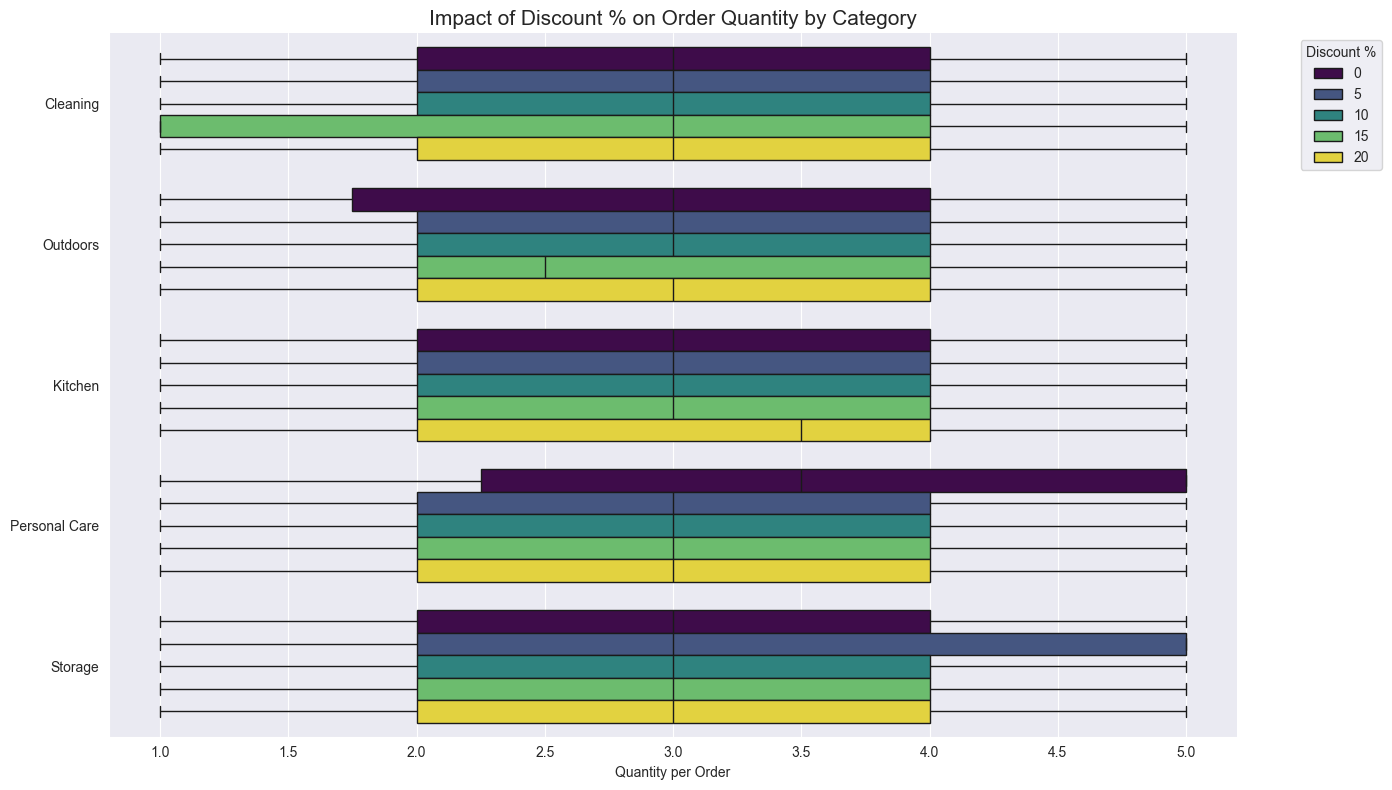

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=master_df,
    x='quantity',
    y='category',
    hue='discount_pct',
    palette='viridis'
)

plt.title('Impact of Discount % on Order Quantity by Category', fontsize=15)
plt.xlabel('Quantity per Order')
plt.ylabel('')
plt.legend(title='Discount %', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()

plt.show()

13a - this correlation matrix shows us that there's no correlation between discounted items and the quantity sold and actually a negative correlation between discounts and revenue validating the previous discovery

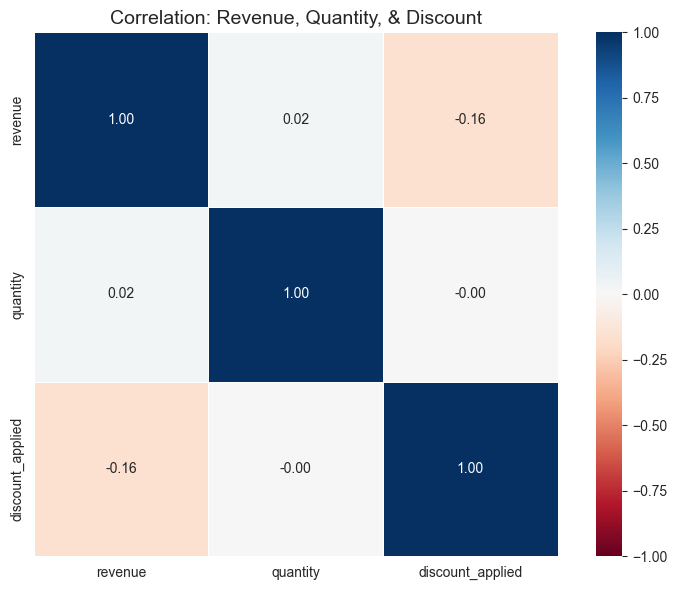

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = ['revenue', 'quantity', 'discount_applied']
corr_matrix = master_df[corr_cols].corr()

# 2. Create the Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='RdBu',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=.5
)

plt.title('Correlation: Revenue, Quantity, & Discount', fontsize=14)
plt.tight_layout()

plt.show()

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plot_df = master_data[master_data['loyalty_tier'] != 'Unknown'].copy()

sns.countplot(
    data=plot_df,
    x='loyalty_tier',
    hue='region_y',
    # 3. Update the order list to remove 'Unknown'
    order=['Bronze', 'Silver', 'Gold'],
    palette='magma'
)

for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{int(p.get_height())}',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha = 'center', va = 'center',
                           xytext = (0, 9),
                           textcoords = 'offset points',
                           fontsize=9)

plt.title('Order Volume by Loyalty Tier & Region (Excl. Unknown Tiers)', fontsize=15)
plt.xlabel('Loyalty Tier')
plt.ylabel('Number of Orders')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()

plt.show()

NameError: name 'master_data' is not defined

<Figure size 1400x700 with 0 Axes>

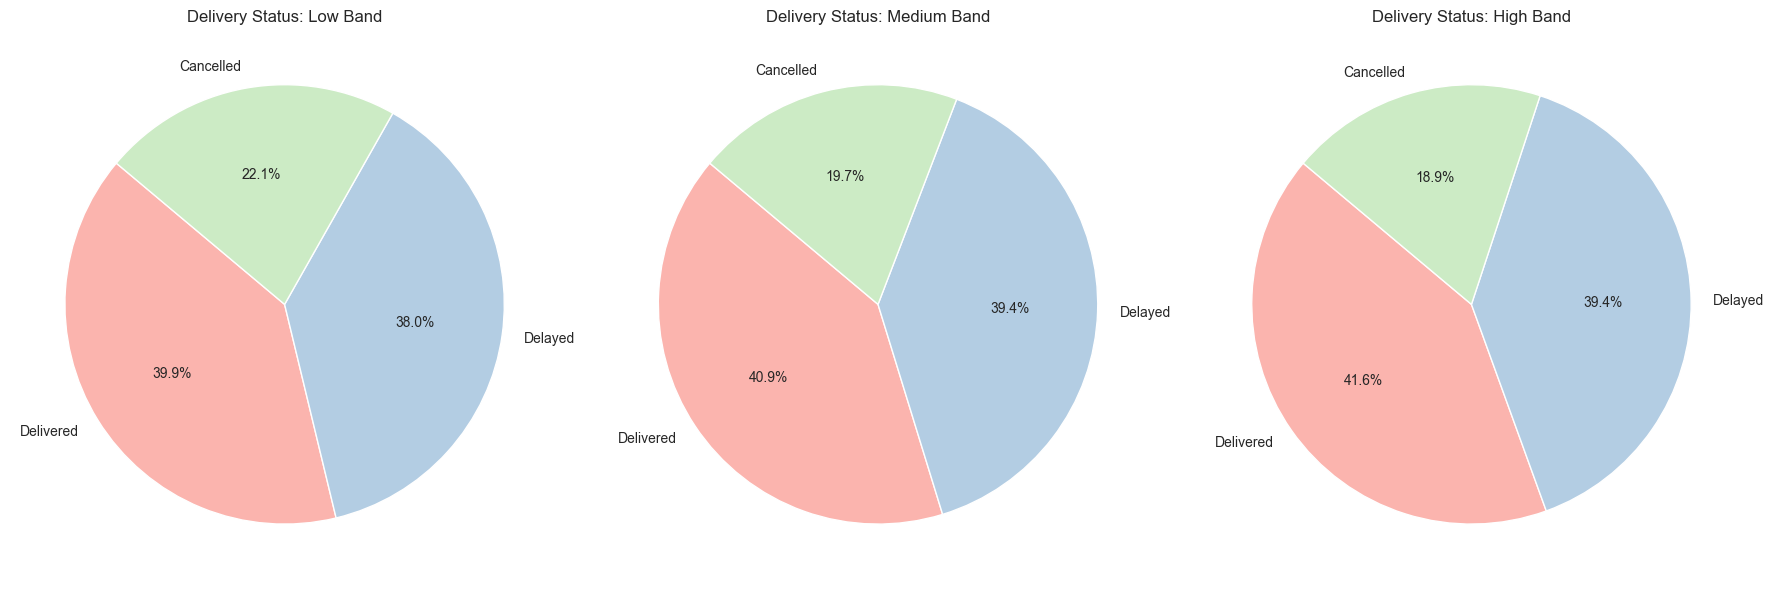

In [103]:
import matplotlib.pyplot as plt

bands = ['Low', 'Medium', 'High']
statuses = master_df['delivery_status'].unique()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, band in enumerate(bands):
    subset = master_df[master_df['price_band'] == band]
    data = subset['delivery_status'].value_counts()

    axes[i].pie(data, labels=data.index, autopct='%1.1f%%',
                startangle=140, colors=plt.cm.Pastel1.colors)
    axes[i].set_title(f'Delivery Status: {band.capitalize()} Band')

plt.tight_layout()
plt.show()